# Current version : 9.D (2025-04-29)

In [ ]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('data/cyc_analysis_nonzero_circa2.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('data/cyc_analysis_nonzero_circa4.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


# Cycling genes

## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [ ]:
import pandas as pd

dir_sum = '../R/Results/2025-06-24_SD1_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-24_SD1_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [ ]:
df

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate = "2025-06-17_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_analysis.xlsx', sheet_name=None)
cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_per_celltype.csv', index_col='cell_type')

In [ ]:
cycling_summary.iloc[1]

In [ ]:
for idx, celltype in enumerate(df_all.keys()):

    # Data preparation
    df = pd.DataFrame(data=zip(df_all[celltype]['CycID'], df_all[celltype]['meta2d_phase']))
    df.columns = ['Gene','Phase']
    df['Radians'] = df['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df['Radians'], bins = 24)

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.savefig(f'Gallery/circa4/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'data/{region}_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
run_namdate_1 = "2025-06-17_circa4"
run_namdate_2 = "2025-06-24_SD1"
run_type = 'celltype'
cell_type_plot = 'Oligodendrocyte'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [3]:
from module.misc import genes_list

gene_list_plot = genes_list("panel_5k")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
# subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
# subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [4]:
data = pd.DataFrame(index=gene_list_plot)

In [5]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [6]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
data.dropna(inplace= True)
data['Gene'] = data.index
# data['Diff'] = abs(data['NS'] - data['SD'])
data = data.sort_values(by='NS')

In [12]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors="black")
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

/tmp/ipykernel_70738/1724161530.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


ValueError: Image size of 583x104927 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 500x500 with 1 Axes>

In [ ]:
# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [8]:
data

,NS,SD,Gene,Radius,Color
Myh9,0.011779,6.424363,Myh9,1,"(0.86, 0.3712, 0.33999999999999997)"
Maz,0.420607,2.048396,Maz,2,"(0.86, 0.3744432432432432, 0.33999999999999997)"
Cdh11,1.000037,4.219570,Cdh11,3,"(0.86, 0.37768648648648645, 0.33999999999999997)"
Ldha,1.000384,21.989824,Ldha,4,"(0.86, 0.3809297297297297, 0.33999999999999997)"
Tpi1,1.000849,4.714840,Tpi1,5,"(0.86, 0.3841729729729729, 0.33999999999999997)"
...,...,...,...,...,...
Il6st,22.010367,4.809684,Il6st,958,"(0.86, 0.35498378378378354, 0.33999999999999997)"
Anapc11,22.017740,5.153893,Anapc11,959,"(0.86, 0.35822702702702736, 0.33999999999999997)"
Paip1,22.104042,4.728545,Paip1,960,"(0.86, 0.3614702702702705, 0.33999999999999997)"
Etnppl,22.161874,8.777070,Etnppl,961,"(0.86, 0.36471351351351367, 0.33999999999999997)"


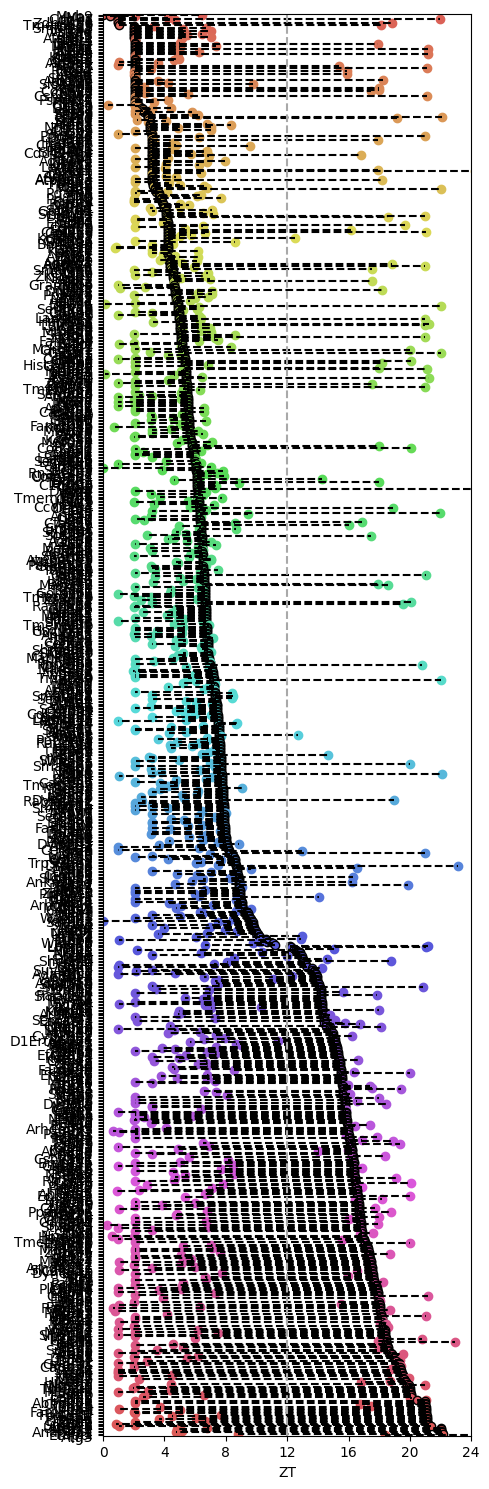

In [10]:
plt.figure(figsize=(5,15))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS")], xmax=data.iloc[n,data.columns.get_loc("SD")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS")],y=n, color = data.iloc[n,data.columns.get_loc("Color")], edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = 12, ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [2]:
run_namdate_1 = "2025-06-17_circa4"
run_namdate_2 = "2025-06-24_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_celltype.csv', index_col='cell_type')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_celltype.csv', index_col='cell_type')

In [3]:
df_NS = pd.read_excel(f'{dir_sum_1}/2025-06-17_circa4_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID'])
df_SD = pd.read_excel(f'{dir_sum_2}/2025-06-24_SD1_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID'])

common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [4]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

Text(0.5, 1.0, 'Cycling genes in normal and disrupted sleep')

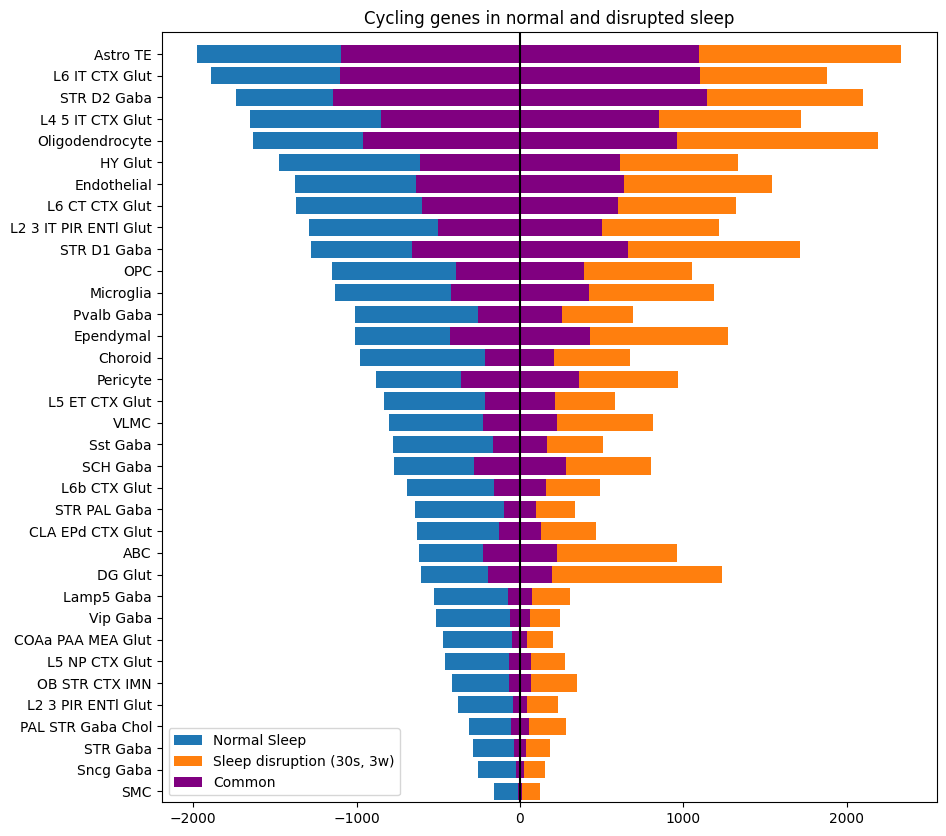

In [5]:
fig, ax = plt.subplots(figsize = (10,10))
ax.barh(y = cycling_summary_1.index, width = -cycling_summary_1['cycling_gene_count'], label = 'Normal Sleep')
ax.barh(y = cycling_summary_2.index, width= cycling_summary_2['cycling_gene_count'], label = 'Sleep disruption (30s, 3w)')
ax.barh(y = sum_com_df.index, width=sum_com_df['Common'], label = 'Common', color = 'purple')
ax.barh(y = sum_com_df.index, width=-sum_com_df['Common'], color = 'purple')
ax.vlines(x=0,ymin=-1,ymax=len(cycling_summary_1), color = "black")
ax.set_ylim(-0.5,len(cycling_summary_1))
ax.legend()
ax.set_title('Cycling genes in normal and disrupted sleep')

# Test Squidpy

In [ ]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
adata = sc.read_h5ad('../notebook/h5ad/circa-SD/circa-SD_final.h5ad.gz')
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'


In [ ]:
# df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# from module.xenium_preprocessing import add_annotations
# df = add_annotations(adata,df)
name_dir = 'circa-SD'
df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet")

In [ ]:
df.sample(3)

In [ ]:
adata = adata[adata.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='CTX']
adata.obsm['spatial'] = adata.obsm['coord_xy']

In [ ]:
adata

In [ ]:
sq.gr.spatial_neighbors(adata)

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="cell type")

In [ ]:
sq.pl.nhood_enrichment(adata, cluster_key="cell type")

# Moran

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata.uns["moranI"].head(15)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gfap",
        "Trem2",
        "Bhlhe22"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Folr1",
        "Slc17a7",
        "Rsph1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp1r1b",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
grp = adata.obs['run'].unique()
grp

In [ ]:
df2 = adata[adata.obs['run'] == 'circa4'].obs.groupby('sample')['region_automap_name'].value_counts()

In [ ]:
df2.to_csv('temp_region_circa4.csv')

# Test run R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
a = 1
print(a)